# Modelación en ingeniería
## Neural Ordinary Differential Equiations

*Profesor: David Ortiz-Puerta*

---

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from helpers import configure_plot_style

configure_plot_style()

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

# --- Modelo: péndulo no lineal con fricción ---
g, L, b = 9.81, 9.81, 0.3      # parámetros canónicos (desconocidos para el identificador)

def pendulum(t, x):
    theta, omega = x
    return [omega, -b*omega - (g/L)*np.sin(theta)]

# --- Configuración de simulación ---
t_span = (0.0, 10.0)
dt     = 0.05
t      = np.arange(t_span[0], t_span[1], dt)
sigma  = 0.00                  # desv. est. del ruido de medición

# --- Múltiples ensayos: distintas condiciones iniciales ---
n_traj = 10
rng    = np.random.default_rng(0)
theta0 = rng.uniform(-np.pi, np.pi, n_traj)     # ángulo inicial
omega0 = rng.uniform(-2.0, 2.0, n_traj)         # velocidad inicial

# --- Simulación de cada trayectoria ---
trajectories = []
for k in range(n_traj):
    sol = solve_ivp(pendulum, t_span, [theta0[k], omega0[k]], t_eval=t)
    X   = sol.y.T                                # (len(t), 2): columnas [theta, omega]
    X_noisy = X + sigma*rng.standard_normal(X.shape)
    trajectories.append(X_noisy)

trajectories = np.array(trajectories)            # (n_traj, len(t), 2)
print(f"Generadas {n_traj} trayectorias, cada una de {len(t)} puntos.")

Generadas 10 trayectorias, cada una de 200 puntos.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint

# 1. Preparación de datos 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
t_tensor = torch.tensor(t, dtype=torch.float32).to(device)
X_tensor = torch.tensor(trajectories, dtype=torch.float32).to(device) # Shape: (12, 200, 2)

# 2. Definición de la Red Neuronal
class NeuralNetwork(nn.Module):
    def __init__(self, hlayers):
        super(NeuralNetwork, self).__init__()
        layers = []
        for i in range(len(hlayers[:-2])):
            layers.append(nn.Linear(hlayers[i], hlayers[i+1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hlayers[-2], hlayers[-1]))

        self.layers = nn.Sequential(*layers)
        self.init_params()

    def init_params(self):
        def init_normal(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
        self.apply(init_normal)

    # CORRECCIÓN 1: Se añade 't' a la firma del método
    def forward(self, t, x):
        return self.layers(x)

torch.manual_seed(123)

hidden_layers = [2, 10, 10, 2]

model = NeuralNetwork(hidden_layers).to(device)
nparams = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of trainable parameters: {nparams}')



cuda
Number of trainable parameters: 162
Epoch 0050 | Loss: 0.379679
Epoch 0100 | Loss: 0.223012
Epoch 0150 | Loss: 0.195952
Epoch 0200 | Loss: 0.174795
Epoch 0250 | Loss: 0.156908
Epoch 0300 | Loss: 0.143712
Epoch 0350 | Loss: 0.134892
Epoch 0400 | Loss: 0.128195
Epoch 0450 | Loss: 0.121580
Epoch 0500 | Loss: 0.113397
Epoch 0550 | Loss: 0.100314
Epoch 0600 | Loss: 0.074644
Epoch 0650 | Loss: 0.038553
Epoch 0700 | Loss: 0.017886
Epoch 0750 | Loss: 0.013176
Epoch 0800 | Loss: 0.010081
Epoch 0850 | Loss: 0.007653
Epoch 0900 | Loss: 0.005647
Epoch 0950 | Loss: 0.004308
Epoch 1000 | Loss: 0.003222


In [ ]:
# 3. Preparación de datos para integración de trayectoria
# Extraemos los 12 estados iniciales. Shape: (12, 2)
x0_full = X_tensor[:, 0, :] 
target_full = X_tensor.transpose(0, 1) 

# 4. Bucle de Entrenamiento
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
epochs = 1000

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    
    # Predicción: integramos todos los estados iniciales por toda la grilla de tiempo 't_tensor'
    prediction = odeint(model, x0_full, t_tensor, method='rk4') 
    
    # Cálculo de pérdida y retropropagación
    loss = loss_fn(prediction, target_full)
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch:04d} | Loss: {loss.item():.6f}")

Error Cuadrático Medio en Validación (OOD): 0.000903


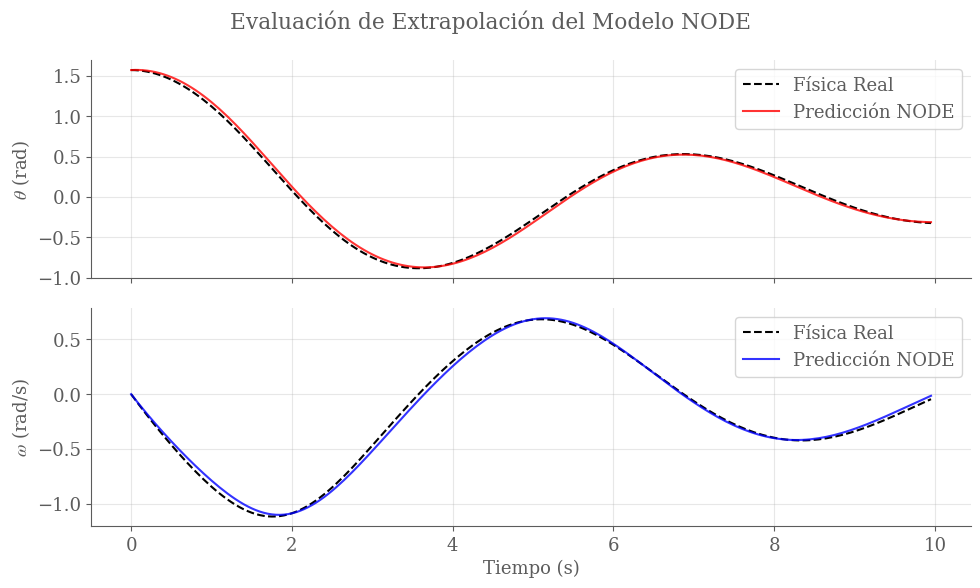

In [40]:
import matplotlib.pyplot as plt

# 1. Generar condición inicial fuera de distribución (OOD)
# Ejemplo: soltar el péndulo desde 90 grados exactos, en reposo
theta0_test = np.pi / 2
omega0_test = 0.0
x0_test_np = np.array([theta0_test, omega0_test])

# 2. Generar Verdad Fundamental (Física Real sin ruido)
sol_test = solve_ivp(pendulum, t_span, x0_test_np, t_eval=t)
X_true = sol_test.y.T  

# 3. Predecir con el modelo NODE
model.eval() 
with torch.no_grad():
    x0_test_tensor = torch.tensor(x0_test_np, dtype=torch.float32).to(device)
    # odeint requiere forma (batch, dim), expandimos la dimensión cero
    prediction_tensor = odeint(model, x0_test_tensor.unsqueeze(0), t_tensor, method='rk4')
    X_pred = prediction_tensor.squeeze(1).cpu().numpy() 

# 4. Métrica de Error de Generalización
mse_test = np.mean((X_true - X_pred)**2)
print(f"Error Cuadrático Medio en Validación (OOD): {mse_test:.6f}")

# 5. Visualización estática del comportamiento dinámico
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Gráfica de Posición Angular
axs[0].plot(t, X_true[:, 0], label='Física Real', color='black', linestyle='--')
axs[0].plot(t, X_pred[:, 0], label='Predicción NODE', color='red', alpha=0.8)
axs[0].set_ylabel(r'$\theta$ (rad)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Gráfica de Velocidad Angular
axs[1].plot(t, X_true[:, 1], label='Física Real', color='black', linestyle='--')
axs[1].plot(t, X_pred[:, 1], label='Predicción NODE', color='blue', alpha=0.8)
axs[1].set_ylabel(r'$\omega$ (rad/s)')
axs[1].set_xlabel('Tiempo (s)')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.suptitle('Evaluación de Extrapolación del Modelo NODE')
plt.tight_layout()
plt.show()

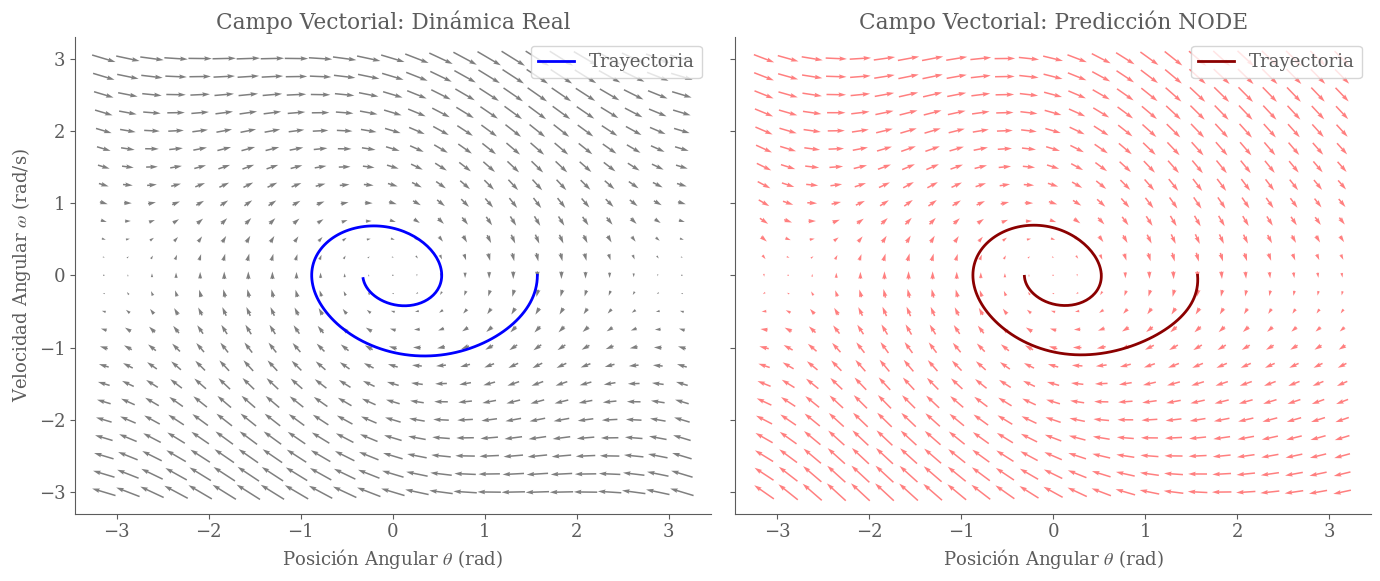

In [ ]:
# 1. Definir la cuadrícula del espacio de fase
theta_vals = np.linspace(-np.pi, np.pi, 25)
omega_vals = np.linspace(-3.0, 3.0, 25)
Theta, Omega = np.meshgrid(theta_vals, omega_vals)

# 2. Calcular vectores del modelo físico real
U_true = Omega
V_true = -0.3 * Omega - (9.81 / 9.81) * np.sin(Theta)

# 3. Calcular vectores del modelo NODE
# Preparar la cuadrícula como tensor para la red neuronal
grid_points = np.vstack([Theta.ravel(), Omega.ravel()]).T
grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    # El sistema es autónomo, el tiempo t=0 es arbitrario para el forward
    t_dummy = torch.tensor(0.0).to(device)
    derivatives_tensor = model(t_dummy, grid_tensor)
    derivatives_pred = derivatives_tensor.cpu().numpy()

U_pred = derivatives_pred[:, 0].reshape(Theta.shape)
V_pred = derivatives_pred[:, 1].reshape(Omega.shape)

# 4. Visualización Comparativa
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Subplot 1: Física Real
axs[0].quiver(Theta, Omega, U_true, V_true, color='black', alpha=0.5, pivot='mid')
# Asumiendo que X_true está definido por tu código de validación previo
axs[0].plot(X_true[:, 0], X_true[:, 1], color='blue', linewidth=2, label='Trayectoria')
axs[0].set_title("Campo Vectorial: Dinámica Real")
axs[0].set_xlabel(r'Posición Angular $\theta$ (rad)')
axs[0].set_ylabel(r'Velocidad Angular $\omega$ (rad/s)')
axs[0].legend()

# Subplot 2: Predicción NODE
axs[1].quiver(Theta, Omega, U_pred, V_pred, color='red', alpha=0.5, pivot='mid')
# Asumiendo que X_pred está definido por tu código de validación previo
axs[1].plot(X_pred[:, 0], X_pred[:, 1], color='darkred', linewidth=2, label='Trayectoria')
axs[1].set_title("Campo Vectorial: Predicción NODE")
axs[1].set_xlabel(r'Posición Angular $\theta$ (rad)')
axs[1].legend()

plt.tight_layout()
plt.show()